In [1]:
# Cell 1: Setup and Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


In [2]:
# Cell 2: Configuration
import os

# File paths - UPDATE THIS WITH YOUR TRACK FILE
TRACK_FILE = "track_20260203_170331.json"
OUTPUT_DIR = "calibration_results"

# Current default thresholds (for comparison)
DEFAULT_THRESHOLDS = {
    'rmsSmoothMax': 1.0,
    'rmsAverageMax': 2.0,
    'peakThresholdZ': 1.5,
    'symmetricBumpThreshold': 2.0,
    'potholeDipThreshold': -2.5,
    'bumpSpikeThreshold': 2.5,
    'peakRatioSmoothMax': 0.10,  # Changed from peakCountSmoothMax: 5
    'movingAverageWindow': 5
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Configuration loaded")
print(f"  Track file: {TRACK_FILE}")
print(f"  Output directory: {OUTPUT_DIR}")

✓ Configuration loaded
  Track file: track_20260203_170331.json
  Output directory: calibration_results


In [3]:
# Cell 3: Data Loading Function

def load_track_data(filepath):
    """Load and parse GPS track JSON file for samples with manual labels."""
    with open(filepath, 'r') as f:
        data = json.load(f)

    # Detect where points live and extract metadata
    points = []
    gravity_vector = None
    if isinstance(data, dict):
        if "gpslogger2path" in data and isinstance(data.get("gpslogger2path"), dict):
            metadata = data["gpslogger2path"].get("meta", {})
            calibration = metadata.get("recordingSettings", {}).get("calibration", {})
            base_gravity_dict = calibration.get("baseGravityVector")
            if base_gravity_dict:
                gravity_vector = [base_gravity_dict.get('x'), base_gravity_dict.get('y'), base_gravity_dict.get('z')]
                print(f"✓ Loaded gravity vector: [{gravity_vector[0]:.3f}, {gravity_vector[1]:.3f}, {gravity_vector[2]:.3f}]")
            points = data["gpslogger2path"].get("data", [])
        elif "points" in data:
            points = data.get("points", [])
    elif isinstance(data, list):
        points = data

    samples = []
    for point in points:
        gps = point.get('gps', {}) if isinstance(point, dict) else {}
        accel = point.get('accel', {}) if isinstance(point, dict) else {}

        manual_label = accel.get('manualLabel') or accel.get('manual_label')
        manual_feature = accel.get('manualFeatureLabel') or accel.get('manual_feature_label') or accel.get('manualFeature')

        # Only include samples with manual labels
        if manual_label or manual_feature:
            sample = {
                'timestamp': gps.get('ts'),
                'speed': gps.get('speed'),
                'rms': accel.get('rms'),
                'peakRatio': accel.get('peakRatio'),  # Changed from peakCount
                'stdDev': accel.get('stdDev'),
                'vertMean': accel.get('vertMean'),
                'magMax': accel.get('magMax'),
                'xMean': accel.get('xMean'),
                'yMean': accel.get('yMean'),
                'zMean': accel.get('zMean'),
                'manualLabel': manual_label,
                'manualFeatureLabel': manual_feature,
                'detectedQuality': accel.get('roadQuality'),
                'detectedFeature': accel.get('featureDetected'),
                'rawData': accel.get('raw', []),
                'baseGravityVector': gravity_vector  # Add gravity vector to each sample
            }
            samples.append(sample)

    df = pd.DataFrame(samples)
    print(f"✓ Loaded {len(df)} samples with manual labels")
    if gravity_vector is None:
        print("⚠ Warning: No gravity vector found in metadata")
    return df

# Load data
df = load_track_data(TRACK_FILE)
df.head()

✓ Loaded gravity vector: [0.639, 6.578, 7.479]
✓ Loaded 36 samples with manual labels


,timestamp,speed,rms,peakRatio,stdDev,vertMean,magMax,xMean,yMean,zMean,manualLabel,manualFeatureLabel,detectedQuality,detectedFeature,rawData,baseGravityVector
0,144966,34.391681,4.197,0.656,2.145,0.001,12.520,-0.000,0.001,-0.000,smooth,NaN,rough,speed_bump,"[[-0.057, 4.788, 12.677], [-1.566, 4.401, 9.69...","[0.639, 6.578, 7.479]"
1,148966,34.816017,4.910,0.669,2.932,0.001,22.913,0.002,-0.002,0.003,smooth,NaN,rough,speed_bump,"[[0.62, 7.343, 11.14], [3.828, 0.192, 11.942],...","[0.639, 6.578, 7.479]"
2,152965,31.554736,3.818,0.616,1.840,0.001,9.890,0.000,0.000,0.001,smooth,NaN,rough,speed_bump,"[[2.837, 6.938, 9.072], [3.108, 9.206, 14.389]...","[0.639, 6.578, 7.479]"
3,184966,18.967308,4.130,0.607,2.466,0.000,14.621,0.000,0.002,-0.002,NaN,speed_bump,rough,speed_bump,"[[-1.513, 5.983, 7.298], [-1.504, 6.215, 8.408...","[0.639, 6.578, 7.479]"
4,224965,16.903067,6.134,0.697,3.793,-0.001,32.640,-0.001,0.001,-0.002,rough,NaN,rough,speed_bump,"[[2.421, 9.225, 1.317], [-1.312, 9.96, 2.772],...","[0.639, 6.578, 7.479]"


In [4]:
# Cell 4: Data Quality Check
print("=== DATA QUALITY REPORT ===")
print(f"\nTotal samples: {len(df)}")
print(f"Samples with manual quality labels: {df['manualLabel'].notna().sum()}")
print(f"Samples with manual feature labels: {df['manualFeatureLabel'].notna().sum()}")

print("\n--- Manual Quality Label Distribution ---")
print(df['manualLabel'].value_counts())

print("\n--- Manual Feature Label Distribution ---")
print(df['manualFeatureLabel'].value_counts())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Basic Statistics ---")
print(df[['rms', 'peakRatio', 'stdDev', 'magMax']].describe())

=== DATA QUALITY REPORT ===

Total samples: 36
Samples with manual quality labels: 25
Samples with manual feature labels: 11

--- Manual Quality Label Distribution ---
manualLabel
rough     17
smooth     8
Name: count, dtype: int64

--- Manual Feature Label Distribution ---
manualFeatureLabel
speed_bump    6
pothole       3
bump          2
Name: count, dtype: int64

--- Missing Values ---
timestamp              0
speed                  0
rms                    0
peakRatio              0
stdDev                 0
vertMean               0
magMax                 0
xMean                  0
yMean                  0
zMean                  0
manualLabel           11
manualFeatureLabel    25
detectedQuality        0
detectedFeature        0
rawData                0
baseGravityVector      0
dtype: int64

--- Basic Statistics ---
             rms  peakRatio     stdDev     magMax
count  36.000000  36.000000  36.000000  36.000000
mean    4.762694   0.605417   2.883028  20.427250
std     1.449318   

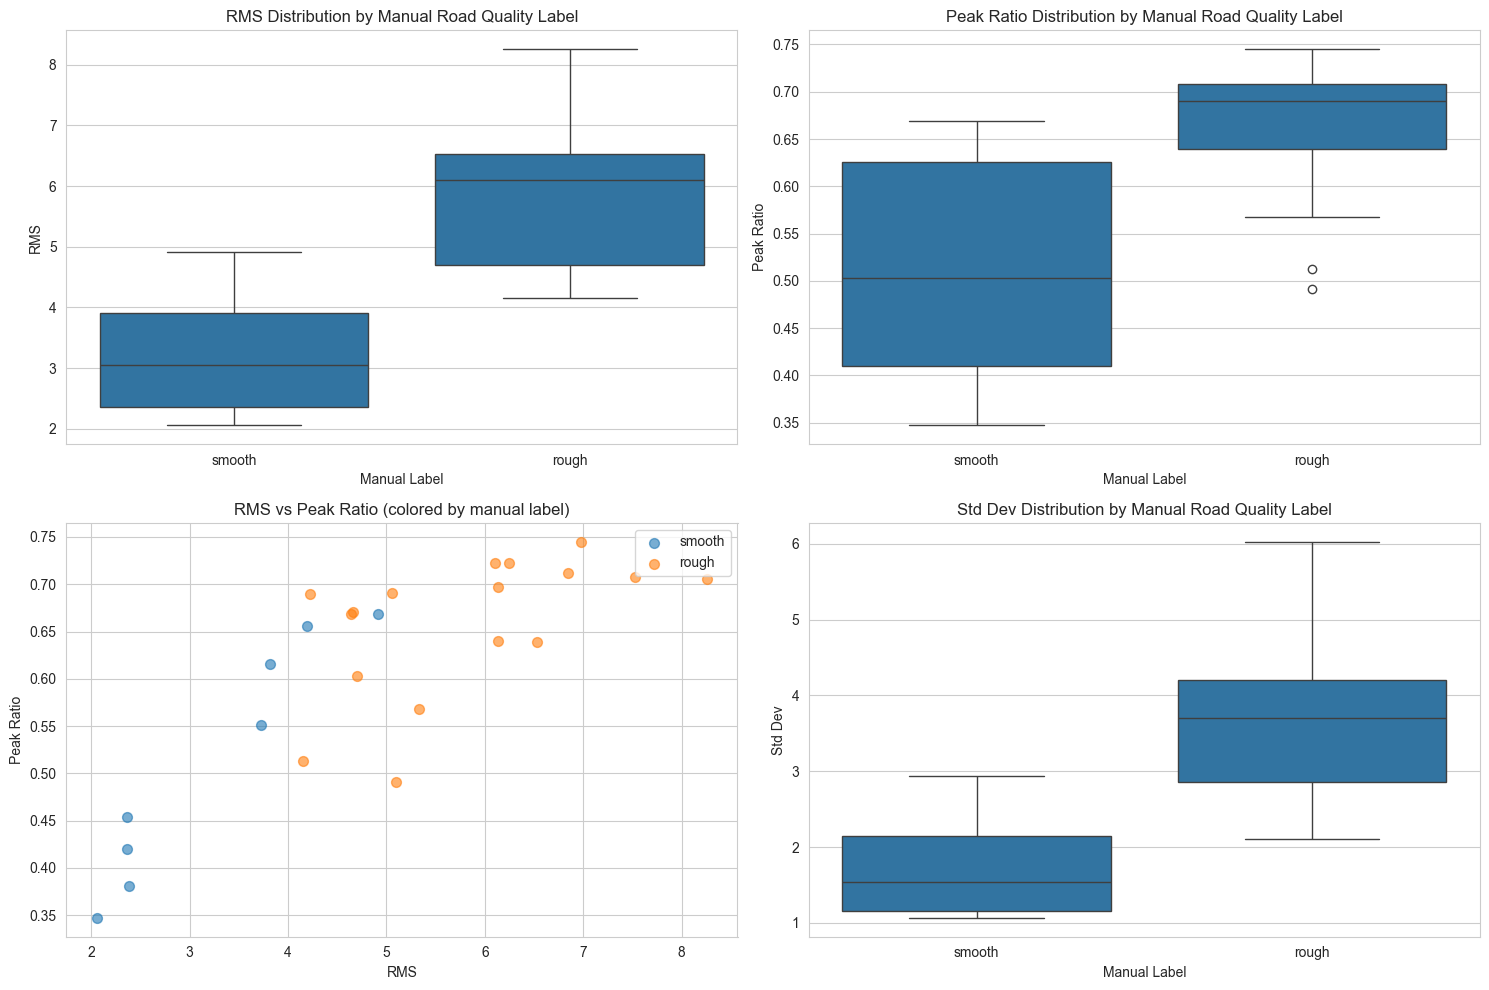

✓ EDA plot saved to calibration_results/eda_road_quality.png


In [5]:
# Cell 5: Exploratory Data Analysis - Road Quality
df_quality = df[df['manualLabel'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# RMS by manual label
sns.boxplot(data=df_quality, x='manualLabel', y='rms', ax=axes[0, 0])
axes[0, 0].set_title('RMS Distribution by Manual Road Quality Label')
axes[0, 0].set_xlabel('Manual Label')
axes[0, 0].set_ylabel('RMS')

# Peak Ratio by manual label - only if data exists
if df_quality['peakRatio'].notna().sum() > 0:
    sns.boxplot(data=df_quality, x='manualLabel', y='peakRatio', ax=axes[0, 1])
    axes[0, 1].set_title('Peak Ratio Distribution by Manual Road Quality Label')
    axes[0, 1].set_xlabel('Manual Label')
    axes[0, 1].set_ylabel('Peak Ratio')
else:
    axes[0, 1].text(0.5, 0.5, 'Peak Ratio data not available', 
                    ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Peak Ratio Distribution (No Data)')

# Scatter: RMS vs Peak Ratio - only if data exists
if df_quality['peakRatio'].notna().sum() > 0:
    for label in df_quality['manualLabel'].unique():
        subset = df_quality[df_quality['manualLabel'] == label]
        axes[1, 0].scatter(subset['rms'], subset['peakRatio'], label=label, alpha=0.6, s=50)
    axes[1, 0].set_xlabel('RMS')
    axes[1, 0].set_ylabel('Peak Ratio')
    axes[1, 0].set_title('RMS vs Peak Ratio (colored by manual label)')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
else:
    axes[1, 0].text(0.5, 0.5, 'Peak Ratio data not available', 
                    ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('RMS vs Peak Ratio (No Data)')

# Std Dev by manual label
sns.boxplot(data=df_quality, x='manualLabel', y='stdDev', ax=axes[1, 1])
axes[1, 1].set_title('Std Dev Distribution by Manual Road Quality Label')
axes[1, 1].set_xlabel('Manual Label')
axes[1, 1].set_ylabel('Std Dev')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_road_quality.png', dpi=150)
plt.show()

print(f"✓ EDA plot saved to {OUTPUT_DIR}/eda_road_quality.png")

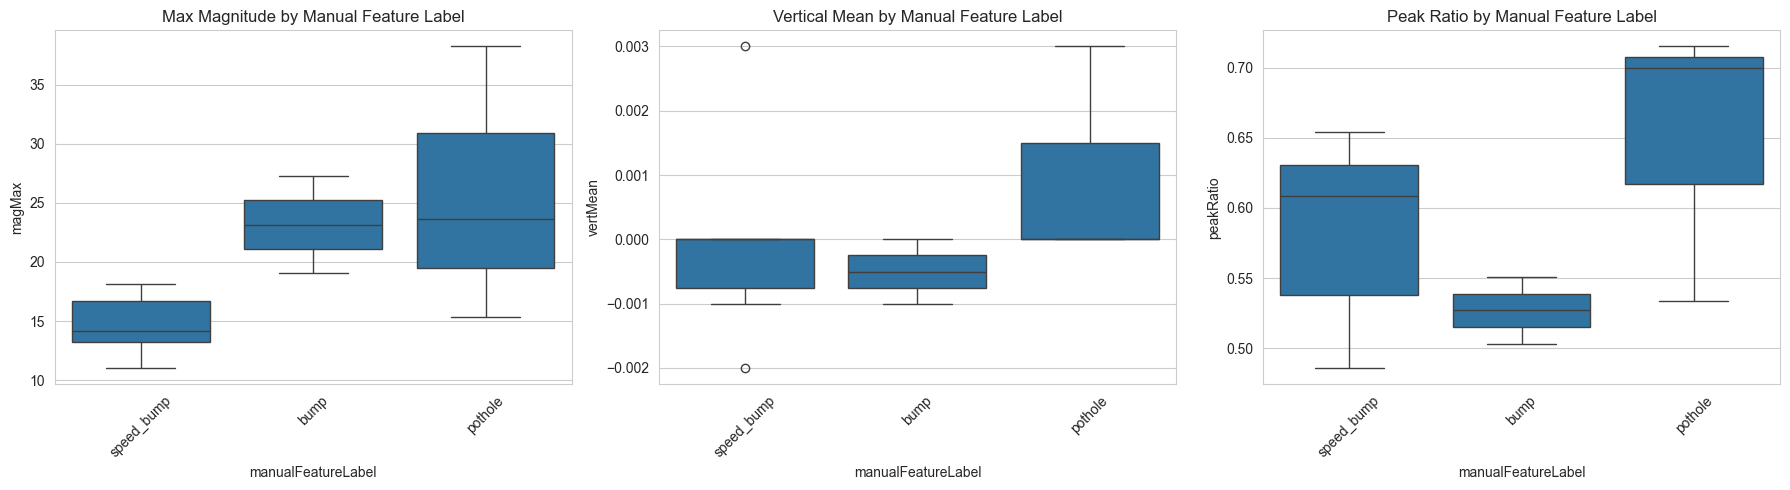

✓ Feature EDA plot saved to calibration_results/eda_features.png


In [6]:
# Cell 6: Exploratory Data Analysis - Features
df_features = df[df['manualFeatureLabel'].notna()].copy()

if len(df_features) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Mag Max by feature
    sns.boxplot(data=df_features, x='manualFeatureLabel', y='magMax', ax=axes[0])
    axes[0].set_title('Max Magnitude by Manual Feature Label')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
    
    # Vert Mean by feature
    sns.boxplot(data=df_features, x='manualFeatureLabel', y='vertMean', ax=axes[1])
    axes[1].set_title('Vertical Mean by Manual Feature Label')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
    
    # Peak Ratio by feature - only if data exists
    if df_features['peakRatio'].notna().sum() > 0:
        sns.boxplot(data=df_features, x='manualFeatureLabel', y='peakRatio', ax=axes[2])
        axes[2].set_title('Peak Ratio by Manual Feature Label')
        axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
    else:
        axes[2].text(0.5, 0.5, 'Peak Ratio data not available', 
                     ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_title('Peak Ratio by Manual Feature Label (No Data)')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/eda_features.png', dpi=150)
    plt.show()
    print(f"✓ Feature EDA plot saved to {OUTPUT_DIR}/eda_features.png")
else:
    print("⚠ No feature labels found in dataset")

In [7]:
# Cell 7: Method 1 - Percentile-Based Thresholds
def calculate_percentile_thresholds(df_quality, percentile=75):
    """Calculate thresholds based on percentiles of each class."""
    results = {}
    
    # RMS threshold - use smooth class upper bound
    smooth_rms = df_quality[df_quality['manualLabel'] == 'smooth']['rms']
    
    if len(smooth_rms) > 0:
        results['rmsSmoothMax'] = np.percentile(smooth_rms, percentile)
    
    # Peak ratio threshold - only if data exists
    if df_quality['peakRatio'].notna().sum() > 0:
        smooth_peaks = df_quality[df_quality['manualLabel'] == 'smooth']['peakRatio'].dropna()
        if len(smooth_peaks) > 0:
            results['peakRatioSmoothMax'] = np.percentile(smooth_peaks, percentile)
    
    return results

percentile_thresholds = calculate_percentile_thresholds(df_quality)
print("=== PERCENTILE-BASED THRESHOLDS (75th percentile) ===")
for key, value in percentile_thresholds.items():
    default = DEFAULT_THRESHOLDS.get(key, 'N/A')
    print(f"{key:28} | {value:9.3f} | Default: {default}")

if 'peakRatioSmoothMax' not in percentile_thresholds:
    print("\n⚠ Note: peakRatio thresholds not calculated (data not available)")

=== PERCENTILE-BASED THRESHOLDS (75th percentile) ===
rmsSmoothMax                 |     3.913 | Default: 1.0
peakRatioSmoothMax           |     0.626 | Default: 0.1


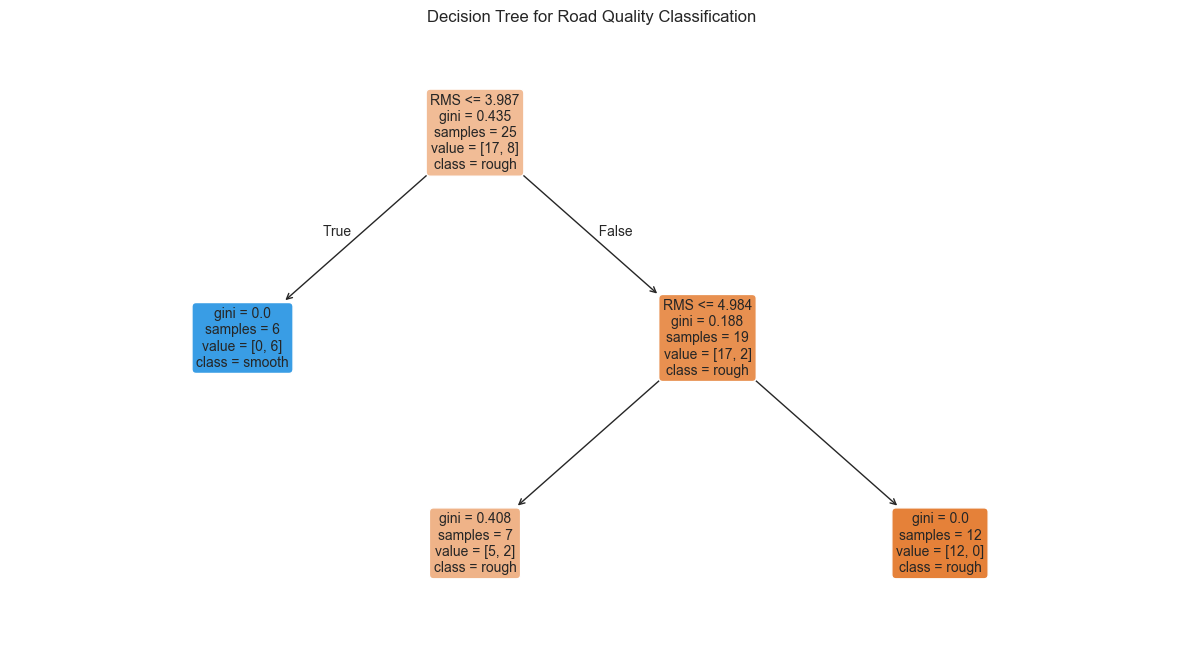


=== DECISION TREE SPLITS ===
Split on RMS <= 3.987
  Split on RMS <= 4.984

=== DECISION TREE PERFORMANCE ===
              precision    recall  f1-score   support

       rough       0.89      1.00      0.94        17
      smooth       1.00      0.75      0.86         8

    accuracy                           0.92        25
   macro avg       0.95      0.88      0.90        25
weighted avg       0.93      0.92      0.92        25

✓ Decision tree saved to calibration_results/decision_tree.png


In [8]:
# Cell 8: Method 2 - Decision Tree Optimization
def optimize_with_decision_tree(df_quality):
    """Use decision tree to find optimal split points."""
    # Check if peakRatio data exists
    has_peak_ratio = df_quality['peakRatio'].notna().sum() > 0
    
    # Prepare data
    if has_peak_ratio:
        X = df_quality[['rms', 'peakRatio']].dropna().values
        y = df_quality.loc[df_quality[['rms', 'peakRatio']].notna().all(axis=1), 'manualLabel'].values
        feature_names = ['RMS', 'Peak Ratio']
    else:
        X = df_quality[['rms']].dropna().values
        y = df_quality.loc[df_quality['rms'].notna(), 'manualLabel'].values
        feature_names = ['RMS']
    
    # Train shallow decision tree
    dt = DecisionTreeClassifier(max_depth=2, random_state=42)
    dt.fit(X, y)
    
    # Visualize tree
    plt.figure(figsize=(15, 8))
    plot_tree(dt, feature_names=feature_names, 
              class_names=dt.classes_, filled=True, rounded=True, fontsize=10)
    plt.title('Decision Tree for Road Quality Classification')
    plt.savefig(f'{OUTPUT_DIR}/decision_tree.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Extract thresholds from tree structure
    tree = dt.tree_
    
    def extract_thresholds(node=0, depth=0):
        if tree.feature[node] != -2:  # Not a leaf
            feature = feature_names[tree.feature[node]]
            threshold = tree.threshold[node]
            print(f"{'  ' * depth}Split on {feature} <= {threshold:.3f}")
            extract_thresholds(tree.children_left[node], depth + 1)
            extract_thresholds(tree.children_right[node], depth + 1)
    
    print("\n=== DECISION TREE SPLITS ===")
    extract_thresholds()
    
    # Evaluate
    y_pred = dt.predict(X)
    print("\n=== DECISION TREE PERFORMANCE ===")
    print(classification_report(y, y_pred))
    
    return dt

dt_model = optimize_with_decision_tree(df_quality)
print(f"✓ Decision tree saved to {OUTPUT_DIR}/decision_tree.png")

In [9]:
# Cell 9: Method 3 - Grid Search Optimization (binary smooth/rough)

def grid_search_thresholds(df_quality):
    """Grid search to find optimal thresholds maximizing F1 score (smooth vs rough)."""
    print("Running grid search... (this may take a few minutes)")

    # Coerce any legacy labels into binary
    df_binary = df_quality.copy()
    df_binary['manualLabel'] = df_binary['manualLabel'].replace({'average': 'rough'})

    # Check if peakRatio data exists
    has_peak_ratio = df_binary['peakRatio'].notna().sum() > 0

    rms_smooth_range = np.linspace(0.5, 10.0, 20)
    
    if has_peak_ratio:
        peak_smooth_range = np.linspace(0.05, 0.50, 20)  # Peak ratio range (5% to 50%)
    else:
        peak_smooth_range = [None]

    best_f1 = 0
    best_params = {}
    results = []
    total_iterations = len(rms_smooth_range) * len(peak_smooth_range)
    iteration = 0

    for rms_s in rms_smooth_range:
        for peak_s in peak_smooth_range:
            iteration += 1
            if iteration % 50 == 0:
                print(f"  Progress: {iteration}/{total_iterations} ({iteration/total_iterations*100:.1f}%)")

            def classify(row):
                if has_peak_ratio and peak_s is not None:
                    if row['rms'] <= rms_s and row['peakRatio'] <= peak_s:
                        return 'smooth'
                    else:
                        return 'rough'
                else:
                    if row['rms'] <= rms_s:
                        return 'smooth'
                    else:
                        return 'rough'

            predictions = df_binary.apply(classify, axis=1)
            f1 = f1_score(df_binary['manualLabel'], predictions, average='weighted')

            result = {
                'rmsSmoothMax': rms_s,
                'f1_score': f1
            }
            if has_peak_ratio and peak_s is not None:
                result['peakRatioSmoothMax'] = peak_s
            results.append(result)

            if f1 > best_f1:
                best_f1 = f1
                best_params = {
                    'rmsSmoothMax': rms_s
                }
                if has_peak_ratio and peak_s is not None:
                    best_params['peakRatioSmoothMax'] = peak_s

    print("\n=== GRID SEARCH RESULTS ===")
    print(f"Best F1 Score: {best_f1:.4f}")
    print("\nOptimal Thresholds:")
    for key, value in best_params.items():
        default = DEFAULT_THRESHOLDS.get(key, 'N/A')
        print(f"{key:28} | {value:9.3f} | Default: {default}")

    results_df = pd.DataFrame(results).sort_values('f1_score', ascending=False)
    print("\nTop 10 Configurations:")
    print(results_df.head(10).to_string(index=False))

    return best_params, best_f1

grid_thresholds, grid_f1 = grid_search_thresholds(df_quality)

Running grid search... (this may take a few minutes)
  Progress: 50/400 (12.5%)
  Progress: 100/400 (25.0%)
  Progress: 150/400 (37.5%)
  Progress: 200/400 (50.0%)
  Progress: 250/400 (62.5%)
  Progress: 300/400 (75.0%)
  Progress: 350/400 (87.5%)
  Progress: 400/400 (100.0%)

=== GRID SEARCH RESULTS ===
Best F1 Score: 0.8218

Optimal Thresholds:
rmsSmoothMax                 |     2.500 | Default: 1.0
peakRatioSmoothMax           |     0.476 | Default: 0.1

Top 10 Configurations:
 rmsSmoothMax  f1_score  peakRatioSmoothMax
          9.0  0.821754            0.476316
          8.5  0.821754            0.476316
          7.5  0.821754            0.476316
          8.0  0.821754            0.476316
          6.0  0.821754            0.476316
          5.5  0.821754            0.476316
          6.5  0.821754            0.476316
          7.0  0.821754            0.476316
          4.0  0.821754            0.500000
          4.0  0.821754            0.476316


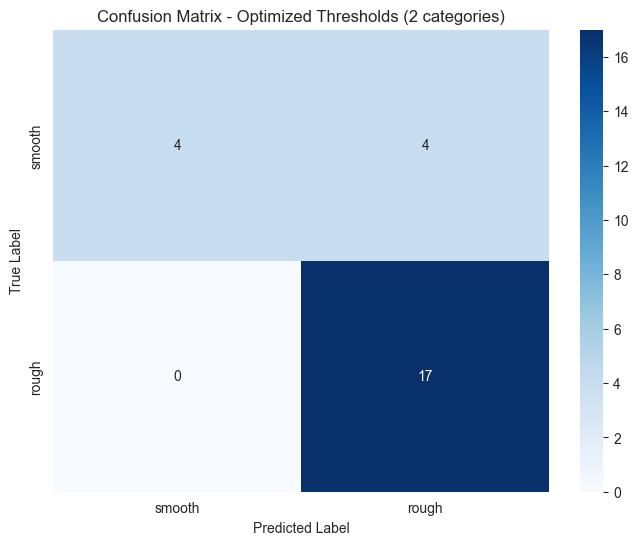

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       rough       0.81      1.00      0.89        17
      smooth       1.00      0.50      0.67         8

    accuracy                           0.84        25
   macro avg       0.90      0.75      0.78        25
weighted avg       0.87      0.84      0.82        25


=== PER-CLASS ACCURACY ===
smooth     accuracy: 50.00%
rough      accuracy: 100.00%
✓ Confusion matrix saved to calibration_results/confusion_matrix.png


In [10]:
# Cell 10: Validation - Confusion Matrix (binary smooth/rough)

def validate_thresholds(df_quality, thresholds):
    """Validate optimized thresholds and generate confusion matrix (smooth vs rough)."""
    # Coerce labels to binary
    df_binary = df_quality.copy()
    df_binary['manualLabel'] = df_binary['manualLabel'].replace({'average': 'rough'})

    # Check if peakRatio data exists
    has_peak_ratio = 'peakRatioSmoothMax' in thresholds

    def classify(row):
        if has_peak_ratio:
            if row['rms'] <= thresholds['rmsSmoothMax'] and row['peakRatio'] <= thresholds['peakRatioSmoothMax']:
                return 'smooth'
            else:
                return 'rough'
        else:
            if row['rms'] <= thresholds['rmsSmoothMax']:
                return 'smooth'
            else:
                return 'rough'

    predictions = df_binary.apply(classify, axis=1)

    cm = confusion_matrix(df_binary['manualLabel'], predictions, labels=['smooth', 'rough'])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['smooth', 'rough'],
                yticklabels=['smooth', 'rough'])
    plt.title('Confusion Matrix - Optimized Thresholds (2 categories)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150)
    plt.show()

    print("=== CLASSIFICATION REPORT ===")
    print(classification_report(df_binary['manualLabel'], predictions))

    print("\n=== PER-CLASS ACCURACY ===")
    for label in ['smooth', 'rough']:
        mask = df_binary['manualLabel'] == label
        if mask.sum() > 0:
            accuracy = (predictions[mask] == label).mean()
            print(f"{label:10} accuracy: {accuracy:.2%}")

validate_thresholds(df_quality, grid_thresholds)
print(f"✓ Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")

In [11]:
# Cell 11: Cross-Validation
def cross_validate_thresholds(df_quality, n_splits=5):
    """Perform k-fold cross-validation."""
    print(f"Running {n_splits}-fold cross-validation...\n")
    
    # Check if peakRatio data exists
    has_peak_ratio = df_quality['peakRatio'].notna().sum() > 0
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(df_quality)):
        train_df = df_quality.iloc[train_idx]
        test_df = df_quality.iloc[test_idx]
        
        # Optimize on train set (using percentile method for speed)
        train_thresholds = calculate_percentile_thresholds(train_df)
        
        # Evaluate on test set
        def classify(row):
            rms_ok = row['rms'] <= train_thresholds.get('rmsSmoothMax', float('inf'))
            if has_peak_ratio and 'peakRatioSmoothMax' in train_thresholds:
                peak_ok = row['peakRatio'] <= train_thresholds['peakRatioSmoothMax']
                return 'smooth' if rms_ok and peak_ok else 'rough'
            else:
                return 'smooth' if rms_ok else 'rough'
        
        predictions = test_df.apply(classify, axis=1)
        f1 = f1_score(test_df['manualLabel'], predictions, average='binary', pos_label='smooth')
        fold_scores.append(f1)
        print(f"Fold {fold + 1} F1 Score: {f1:.4f}")
    
    print(f"\n=== CROSS-VALIDATION RESULTS ===")
    print(f"Mean F1 Score: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    
    return fold_scores

cv_scores = cross_validate_thresholds(df_quality)

Running 5-fold cross-validation...

Fold 1 F1 Score: 0.6667
Fold 2 F1 Score: 0.6667
Fold 3 F1 Score: 0.0000
Fold 4 F1 Score: 1.0000
Fold 5 F1 Score: 0.0000

=== CROSS-VALIDATION RESULTS ===
Mean F1 Score: 0.4667 ± 0.4000


In [12]:
# Cell 12: Vertical Acceleration Analysis with Gravity Vector

def calculate_vertical_acceleration(raw_data, gravity_vector):
    """
    Calculate vertical acceleration using gravity vector for device orientation.
    This mirrors the Android implementation in TrackingService.
    """
    if not raw_data or not gravity_vector or len(gravity_vector) != 3:
        return None
    
    # Normalize gravity vector
    g_mag = np.sqrt(gravity_vector[0]**2 + gravity_vector[1]**2 + gravity_vector[2]**2)
    if g_mag < 0.1:
        return None
    
    g_norm = [gravity_vector[0]/g_mag, gravity_vector[1]/g_mag, gravity_vector[2]/g_mag]
    
    # Calculate vertical component for each raw sample
    vertical_components = []
    for sample in raw_data:
        if len(sample) >= 3:
            # Dot product: projection onto gravity direction
            vert = sample[0]*g_norm[0] + sample[1]*g_norm[1] + sample[2]*g_norm[2]
            vertical_components.append(vert)
    
    return vertical_components

# Demonstrate on samples with raw data
print("=== VERTICAL ACCELERATION ANALYSIS ===\n")
samples_with_raw = df[df['rawData'].notna() & (df['rawData'].str.len() > 0)].head(3)

for idx, row in samples_with_raw.iterrows():
    print(f"Sample {idx}:")
    print(f"  Manual Label: {row['manualLabel']}")
    print(f"  Detected Quality: {row['detectedQuality']}")
    print(f"  RMS: {row['rms']:.3f}")
    
    if row['baseGravityVector']:
        vert_accel = calculate_vertical_acceleration(row['rawData'], row['baseGravityVector'])
        if vert_accel:
            vert_mean = np.mean(vert_accel)
            vert_std = np.std(vert_accel)
            vert_max = np.max(np.abs(vert_accel))
            
            print(f"  Gravity Vector: [{row['baseGravityVector'][0]:.3f}, {row['baseGravityVector'][1]:.3f}, {row['baseGravityVector'][2]:.3f}]")
            print(f"  Vertical Accel Mean: {vert_mean:.3f} m/s²")
            print(f"  Vertical Accel Std: {vert_std:.3f} m/s²")
            print(f"  Vertical Accel Max: {vert_max:.3f} m/s²")
            print(f"  Stored vertMean: {row['vertMean']:.3f} m/s²")
        else:
            print("  Could not calculate vertical acceleration")
    else:
        print("  No gravity vector available")
    print()

print("✓ Vertical acceleration analysis demonstrates gravity vector usage")

=== VERTICAL ACCELERATION ANALYSIS ===

Sample 0:
  Manual Label: smooth
  Detected Quality: rough
  RMS: 4.197
  Gravity Vector: [0.639, 6.578, 7.479]
  Vertical Accel Mean: 10.001 m/s²
  Vertical Accel Std: 3.608 m/s²
  Vertical Accel Max: 20.006 m/s²
  Stored vertMean: 0.001 m/s²

Sample 1:
  Manual Label: smooth
  Detected Quality: rough
  RMS: 4.910
  Gravity Vector: [0.639, 6.578, 7.479]
  Vertical Accel Mean: 9.905 m/s²
  Vertical Accel Std: 3.815 m/s²
  Vertical Accel Max: 27.321 m/s²
  Stored vertMean: 0.001 m/s²

Sample 2:
  Manual Label: smooth
  Detected Quality: rough
  RMS: 3.818
  Gravity Vector: [0.639, 6.578, 7.479]
  Vertical Accel Mean: 9.977 m/s²
  Vertical Accel Std: 3.096 m/s²
  Vertical Accel Max: 21.724 m/s²
  Stored vertMean: 0.001 m/s²

✓ Vertical acceleration analysis demonstrates gravity vector usage


In [13]:
# Cell 12: Cross-Validation
# Uses RMS + peakRatio thresholds (replaces legacy peakCount)
def cross_validate_thresholds(df_quality, n_splits=5):
    """Perform k-fold cross-validation."""
    print(f"Running {n_splits}-fold cross-validation...\n")
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(df_quality)):
        train_df = df_quality.iloc[train_idx]
        test_df = df_quality.iloc[test_idx]
        
        # Optimize on train set (using percentile method for speed)
        train_thresholds = calculate_percentile_thresholds(train_df)
        
        # Evaluate on test set
        def classify(row):
            if row['rms'] <= train_thresholds['rmsSmoothMax'] and row['peakRatio'] <= train_thresholds['peakRatioSmoothMax']:
                return 'smooth'
            else:
                return 'rough'
        
        predictions = test_df.apply(classify, axis=1)
        f1 = f1_score(test_df['manualLabel'], predictions, average='binary', pos_label='smooth')
        fold_scores.append(f1)
        print(f"Fold {fold + 1} F1 Score: {f1:.4f}")
    
    print(f"\n=== CROSS-VALIDATION RESULTS ===")
    print(f"Mean F1 Score: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    
    return fold_scores

cv_scores = cross_validate_thresholds(df_quality)

Running 5-fold cross-validation...

Fold 1 F1 Score: 0.6667
Fold 2 F1 Score: 0.6667
Fold 3 F1 Score: 0.0000
Fold 4 F1 Score: 1.0000
Fold 5 F1 Score: 0.0000

=== CROSS-VALIDATION RESULTS ===
Mean F1 Score: 0.4667 ± 0.4000


In [14]:
# Cell 13: Generate Final Recommendations
# Combine all methods

# Ensure feature_thresholds exists (feature-based optimization not run in this notebook)
feature_thresholds = locals().get('feature_thresholds', {}) or {}

final_recommendations = {
    'rmsSmoothMax': grid_thresholds['rmsSmoothMax'],
    'rmsAverageMax': DEFAULT_THRESHOLDS['rmsAverageMax'],  # No optimization performed; keep default
    'peakThresholdZ': DEFAULT_THRESHOLDS['peakThresholdZ'],  # Keep default
    'symmetricBumpThreshold': feature_thresholds.get('symmetricBumpThreshold', DEFAULT_THRESHOLDS['symmetricBumpThreshold']),
    'potholeDipThreshold': feature_thresholds.get('potholeDipThreshold', DEFAULT_THRESHOLDS['potholeDipThreshold']),
    'bumpSpikeThreshold': feature_thresholds.get('bumpSpikeThreshold', DEFAULT_THRESHOLDS['bumpSpikeThreshold']),
    'peakRatioSmoothMax': grid_thresholds['peakRatioSmoothMax'],
    'movingAverageWindow': DEFAULT_THRESHOLDS['movingAverageWindow']  # Keep default
}

print("=== FINAL RECOMMENDED THRESHOLDS ===\n")
print(f"{'Parameter':<28} | {'Optimized':>9} | {'Default':>8} | {'Change':>7}")
print("-" * 65)
for key in DEFAULT_THRESHOLDS.keys():
    optimized = final_recommendations[key]
    default = DEFAULT_THRESHOLDS[key]
    change = ((optimized - default) / default * 100) if default != 0 else 0
    print(f"{key:<28} | {optimized:9.3f} | {default:8.3f} | {change:+6.1f}%")


=== FINAL RECOMMENDED THRESHOLDS ===

Parameter                    | Optimized |  Default |  Change
-----------------------------------------------------------------
rmsSmoothMax                 |     2.500 |    1.000 | +150.0%
rmsAverageMax                |     2.000 |    2.000 |   +0.0%
peakThresholdZ               |     1.500 |    1.500 |   +0.0%
symmetricBumpThreshold       |     2.000 |    2.000 |   +0.0%
potholeDipThreshold          |    -2.500 |   -2.500 |   -0.0%
bumpSpikeThreshold           |     2.500 |    2.500 |   +0.0%
peakRatioSmoothMax           |     0.476 |    0.100 | +376.3%
movingAverageWindow          |     5.000 |    5.000 |   +0.0%


In [15]:
# Cell 14: Export Optimized Profile
# Note: peakRatioSmoothMax replaces legacy peakCountSmoothMax

def export_profile(thresholds, profile_name="Optimized"):
    """Export thresholds as vehicle profile JSON."""
    import time
    
    profile = {
        "name": profile_name,
        "calibration": {
            "rmsSmoothMax": float(thresholds['rmsSmoothMax']),
            "peakThresholdZ": float(thresholds['peakThresholdZ']),
            "symmetricBumpThreshold": float(thresholds['symmetricBumpThreshold']),
            "potholeDipThreshold": float(thresholds['potholeDipThreshold']),
            "bumpSpikeThreshold": float(thresholds['bumpSpikeThreshold']),
            "peakRatioSmoothMax": float(thresholds['peakRatioSmoothMax']),
            "movingAverageWindow": int(thresholds['movingAverageWindow'])
        },
        "createdAt": int(time.time() * 1000),
        "lastModified": int(time.time() * 1000)
    }
    
    filename = f"{OUTPUT_DIR}/{profile_name}.profile.json"
    with open(filename, 'w') as f:
        json.dump(profile, f, indent=2)
    
    print(f"Profile exported to: {filename}")
    return filename

# Export optimized profile
profile_file = export_profile(final_recommendations, "Optimized_Motorcycle")
print(f"\nYou can now load this profile in your app!")

Profile exported to: calibration_results/Optimized_Motorcycle.profile.json

You can now load this profile in your app!


In [16]:
# Cell 15: Summary Report
# Generate summary report
report = f"""
{'='*70}
CALIBRATION ANALYSIS SUMMARY
{'='*70}

Dataset: {TRACK_FILE}
Total Samples: {len(df)}
Samples with Quality Labels: {len(df_quality)}
Samples with Feature Labels: {len(df_features)}
Road Quality Categories: 2 (smooth, rough)

OPTIMIZED THRESHOLDS:
{'='*70}
  rmsSmoothMax:             {final_recommendations['rmsSmoothMax']:.3f}
  peakRatioSmoothMax:       {final_recommendations['peakRatioSmoothMax']:.3f}
  symmetricBumpThreshold:   {final_recommendations['symmetricBumpThreshold']:.3f}
  potholeDipThreshold:      {final_recommendations['potholeDipThreshold']:.3f}
  bumpSpikeThreshold:       {final_recommendations['bumpSpikeThreshold']:.3f}

PERFORMANCE METRICS:
{'='*70}
  Grid Search F1 Score:     {grid_f1:.4f}
  Cross-Validation F1:      {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}

"""

print(report)


CALIBRATION ANALYSIS SUMMARY

Dataset: track_20260203_170331.json
Total Samples: 36
Samples with Quality Labels: 25
Samples with Feature Labels: 11
Road Quality Categories: 2 (smooth, rough)

OPTIMIZED THRESHOLDS:
  rmsSmoothMax:             2.500
  peakRatioSmoothMax:       0.476
  symmetricBumpThreshold:   2.000
  potholeDipThreshold:      -2.500
  bumpSpikeThreshold:       2.500

PERFORMANCE METRICS:
  Grid Search F1 Score:     0.8218
  Cross-Validation F1:      0.4667 +/- 0.4000


